In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Leitura e preparação dos dados
# ------------------------------------------------------------
df = pd.read_csv('hyperparameter_search_summary.csv')

# Criar colunas auxiliares
df['architecture'] = (
    'emb' + df['embedding_dim'].astype(str) + 
    '_h' + df['heads'].astype(str) + 
    '_l' + df['layers'].astype(str)
)
df['heads_layers'] = 'h' + df['heads'].astype(str) + '_l' + df['layers'].astype(str)

# Paleta de cores: use chaves como string
embedding_colors = {'12': '#1f77b4', '24': '#ff7f0e'}

# ------------------------------------------------------------
# 2. Boxplot de Perplexidade (corrigido)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
# Converte embedding_dim para string temporariamente ou usa hue
sns.boxplot(
    data=df, x='embedding_dim', y='test_perplexity',
    palette=embedding_colors, width=0.5
)
sns.stripplot(
    data=df, x='embedding_dim', y='test_perplexity',
    color='black', alpha=0.4, size=3, jitter=0.2
)
plt.yscale('log')
plt.xlabel('Embedding Dimension', fontsize=12)
plt.ylabel('Test Perplexity (log scale)', fontsize=12)
plt.title('Impact of Embedding Dimension on Test Perplexity', fontsize=14, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

median_12 = df[df['embedding_dim']==12]['test_perplexity'].median()
median_24 = df[df['embedding_dim']==24]['test_perplexity'].median()
reduction = (median_12 - median_24) / median_12 * 100
plt.text(0.5, median_12*1.5, f'Median reduction: {reduction:.0f}%',
         ha='center', fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('boxplot_perplexity_by_embedding.png', dpi=150)
plt.show()

In [ ]:
# ------------------------------------------------------------
# 3. Visualização 2: Heatmap de BLEU médio por combinação
#    arquitetural (embedding_dim vs heads_layers)
# ------------------------------------------------------------
# Calcular média de BLEU para cada combinação
pivot_bleu = df.pivot_table(
    index='embedding_dim', columns='heads_layers',
    values='test_avg_bleu', aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_bleu, annot=True, fmt='.3f', cmap='YlGnBu',
    linewidths=0.5, cbar_kws={'label': 'Mean BLEU'}
)
plt.title('Mean Test BLEU by Architecture Combination', fontsize=14, weight='bold')
plt.xlabel('Heads & Layers', fontsize=12)
plt.ylabel('Embedding Dimension', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_bleu_architecture.png', dpi=150)
plt.show()


In [33]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

def plot_parallel_coordinates(
    file: str, 
    color_metric: str = 'test_perplexity',
    base_font_size: int = 18,      # Tamanho base para labels e ticks
    title_font_size: int = 24,     # Tamanho do título
    colorbar_font_size: int = 16   # Tamanho da barra de cores
):
    """
    Gera um gráfico de coordenadas paralelas com rótulos didáticos e fontes ajustáveis.
    
    Parâmetros:
    - file: caminho do arquivo CSV (sem extensão)
    - color_metric: métrica usada para colorir as linhas
    - base_font_size: tamanho da fonte para labels dos eixos e ticks (via layout.font)
    - title_font_size: tamanho da fonte do título
    - colorbar_font_size: tamanho da fonte do título da barra de cores
    """
    # 1. Carregar os dados
    df = pd.read_csv(f'{file}.csv')
    
    # 2. Mapeamento de nomes técnicos para rótulos didáticos
    label_map = {
        'embedding_dim': 'Embedding Dimension',
        'heads': 'Attention Heads',
        'layers': 'Transformer Layers',
        'drop_rate': 'Dropout Rate',
        'num_epochs': 'Epochs',
        'batch_size': 'Batch Size',
        'lr': 'Learning Rate',
        'number_parameter': 'Number of Parameters',
        'cpp_model_size': 'Model Size (bytes)',
        'test_avg_loss': 'Test Loss',
        'test_perplexity': 'Test Perplexity',
        'log10_test_perplexity': 'Log10(Perplexity)',
        'test_token_accuracy': 'Token Accuracy (Test)',
        'test_avg_bleu': 'BLEU Score (Test)',
        'test_exact_match_rate': 'Exact Match (Test)'
    }
    
    # 3. Excluir colunas desnecessárias
    cols_to_drop = ['config_id', 
                    'train_avg_loss', 'train_perplexity', 'train_token_accuracy',
                    'train_num_samples', 'train_avg_bleu', 'train_exact_match_rate']
    df_plot = df.drop(columns=cols_to_drop)
    
    # 4. Criar coluna logarítmica para perplexidade
    df_plot['log10_test_perplexity'] = np.log10(df_plot['test_perplexity'])
    
    # 5. Ordem das dimensões
    dimension_order = [
        'embedding_dim', 'heads', 'layers', 'drop_rate',
        'num_epochs', 'batch_size', 'lr',
        'number_parameter', 'cpp_model_size',
        'test_avg_loss', 'log10_test_perplexity', 
        'test_token_accuracy', 'test_avg_bleu', 'test_exact_match_rate'
    ]
    
    # 6. Construir as dimensões SEM propriedades de fonte inválidas
    dimensions = []
    for col in dimension_order:
        if col not in df_plot.columns:
            continue
        
        display_label = label_map.get(col, col)
        
        if col in ['embedding_dim', 'heads', 'layers', 'batch_size']:
            # Categórica: mapear para inteiros e definir ticks
            unique_vals = sorted(df_plot[col].unique())
            mapping = {val: i for i, val in enumerate(unique_vals)}
            num_values = df_plot[col].map(mapping).tolist()
            dim_dict = dict(
                label=display_label,
                values=num_values,
                tickvals=list(mapping.values()),
                ticktext=[str(v) for v in unique_vals]
            )
        else:
            # Numérica contínua
            dim_dict = dict(
                label=display_label,
                values=df_plot[col].tolist()
            )
        dimensions.append(dim_dict)
    
    # 7. Definir a métrica de cor e escala
    if color_metric == 'test_perplexity':
        color_values = df_plot['test_perplexity'].tolist()
        colorscale = 'Viridis_r'
        colorbar_title = "Test Perplexity (↓ better)"
    elif color_metric == 'log10_test_perplexity':
        color_values = df_plot['log10_test_perplexity'].tolist()
        colorscale = 'Viridis_r'
        colorbar_title = "Log10 Perplexity (↓ better)"
    else:
        color_values = df_plot[color_metric].tolist()
        colorscale = 'Viridis'
        colorbar_title = label_map.get(color_metric, color_metric)
    
    # 8. Criar figura
    fig = go.Figure(data=go.Parcoords(
        line=dict(
            color=color_values,
            colorscale=colorscale,
            showscale=True,
            colorbar=dict(
                title=dict(
                    text=colorbar_title,
                    font=dict(size=colorbar_font_size, family='Arial')
                ),
                tickfont=dict(size=colorbar_font_size-2, family='Arial')
            )
        ),
        dimensions=dimensions
    ))
    
    # 9. Layout com fontes ajustadas
    width = 2300
    height = 800
    fig.update_layout(
        title=dict(
            #text=f"Parallel Coordinates – Hyperparameter Search (colored by {label_map.get(color_metric, color_metric)})",
            font=dict(size=title_font_size, family='Arial', color='black')
        ),
        font=dict(size=base_font_size, family='Arial'),   # Controla labels dos eixos e ticks
        width=width,
        height=height,
        margin=dict(l=90, r=80, t=100, b=60),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )
    
    # 10. Salvar e exibir
    output_file = f"{file}_parallel_{color_metric}.pdf"
    fig.write_image(output_file, width=width, height=height)
    print(f"Gráfico salvo como: {output_file}")
    fig.show()

# Exemplo de uso
plot_parallel_coordinates('hyperparameter_search_summary', 
                          color_metric='test_avg_loss',
                          base_font_size=20,
                          title_font_size=28)

Gráfico salvo como: hyperparameter_search_summary_parallel_test_avg_loss.pdf


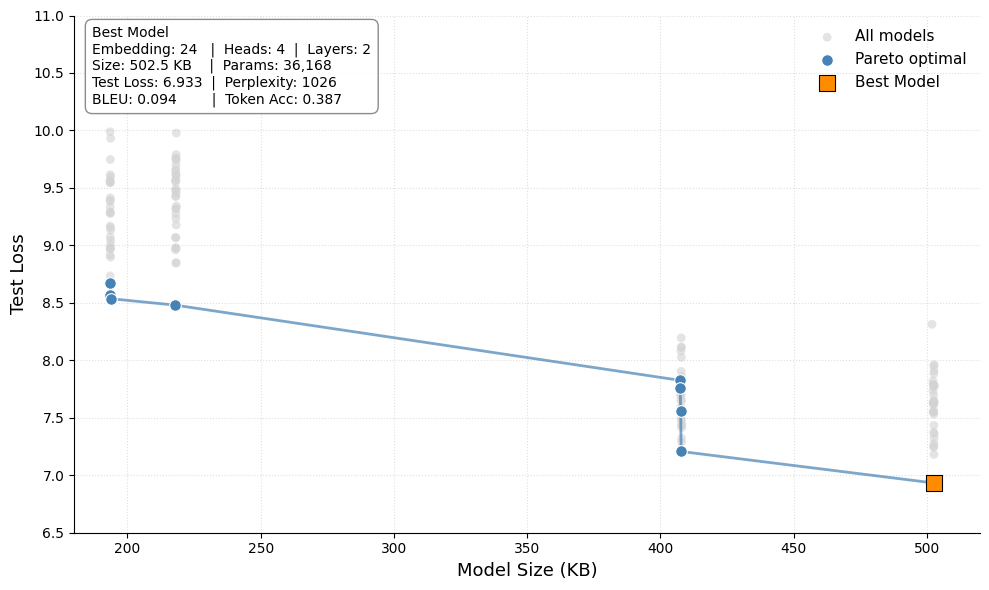

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load and prepare data
# ------------------------------------------------------------
df = pd.read_csv('hyperparameter_search_summary.csv')
df['model_size_kb'] = df['cpp_model_size'] / 1024

# ------------------------------------------------------------
# 2. Identify Pareto frontier
# ------------------------------------------------------------
df_sorted = df.sort_values('model_size_kb')
pareto = []
min_loss = float('inf')
for _, row in df_sorted.iterrows():
    if row['test_avg_loss'] < min_loss:
        min_loss = row['test_avg_loss']
        pareto.append(row)
df_pareto = pd.DataFrame(pareto)

# ------------------------------------------------------------
# 3. Select candidate model (example: specific config or best loss)
# ------------------------------------------------------------
# Here we pick a specific promising configuration; adjust criteria as needed.
candidate = df[df['config_id'] == "emb24_h4_l2_d001_ep300_bs8_lr001"]

if candidate.empty:
    # Fallback: model with lowest test loss on Pareto frontier
    candidate = df_pareto.loc[df_pareto['test_avg_loss'].idxmin()].to_frame().T

row = candidate.iloc[0]

# ------------------------------------------------------------
# 4. Minimalist Pareto plot with embedded info box
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# All models (background)
plt.scatter(
    df['model_size_kb'], df['test_avg_loss'],
    c='lightgray', s=40, alpha=0.6, edgecolors='none', label='All models'
)

# Pareto frontier
plt.scatter(
    df_pareto['model_size_kb'], df_pareto['test_avg_loss'],
    c='steelblue', s=70, edgecolors='white', linewidth=0.8, zorder=3, label='Pareto optimal'
)
plt.plot(
    df_pareto['model_size_kb'], df_pareto['test_avg_loss'],
    color='steelblue', linewidth=2, alpha=0.7, zorder=2
)

# Highlight candidate
plt.scatter(
    row['model_size_kb'], row['test_avg_loss'],
    c='darkorange', s=120, marker='s', edgecolors='black', linewidth=0.8,
    zorder=4, label='Best Model'
)

# Axes labels and title
plt.xlabel('Model Size (KB)', fontsize=13)
plt.ylabel('Test Loss', fontsize=13)
#plt.title('Pareto Frontier: Model Size vs. Test Loss', fontsize=15, weight='semibold')

# Light grid and legend
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=False, fontsize=11)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set limits
plt.xlim(180, 520)
plt.ylim(6.5, 11.0)

# ------------------------------------------------------------
# 5. Add information box with candidate hyperparameters
# ------------------------------------------------------------
info_text = (
    f"Best Model\n"
    f"Embedding: {int(row['embedding_dim'])}   |  Heads: {int(row['heads'])}  |  Layers: {int(row['layers'])}\n"
    f"Size: {row['model_size_kb']:.1f} KB    |  Params: {int(row['number_parameter']):,}\n"
    f"Test Loss: {row['test_avg_loss']:.3f}  |  Perplexity: {row['test_perplexity']:.0f}\n"
    f"BLEU: {row['test_avg_bleu']:.3f}        |  Token Acc: {row['test_token_accuracy']:.3f}"
)

# Position the box in the upper left area (adjust coordinates as needed)
plt.text(
    0.02, 0.98, info_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

plt.tight_layout()
plt.savefig('pareto_with_infobox.pdf', dpi=150, bbox_inches='tight')
plt.show()